In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("ev_sales_price_data.csv")

# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Create Date column
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" + df["Month"].astype(str)
)

# Sort chronologically
df = df.sort_values("Date")

<class 'pandas.core.frame.DataFrame'>
Index: 2640 entries, 872 to 1173
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Year                  2640 non-null   int64         
 1   Month                 2640 non-null   int64         
 2   Region                2640 non-null   object        
 3   Model                 2640 non-null   object        
 4   Estimated_Deliveries  2640 non-null   int64         
 5   Production_Units      2640 non-null   int64         
 6   Avg_Price_USD         2640 non-null   float64       
 7   Battery_Capacity_kWh  2640 non-null   int64         
 8   Range_km              2640 non-null   int64         
 9   CO2_Saved_tons        2640 non-null   float64       
 10  Source_Type           2640 non-null   object        
 11  Charging_Stations     2640 non-null   int64         
 12  Date                  2640 non-null   datetime64[ns]
dtypes: datetime64[ns](1),

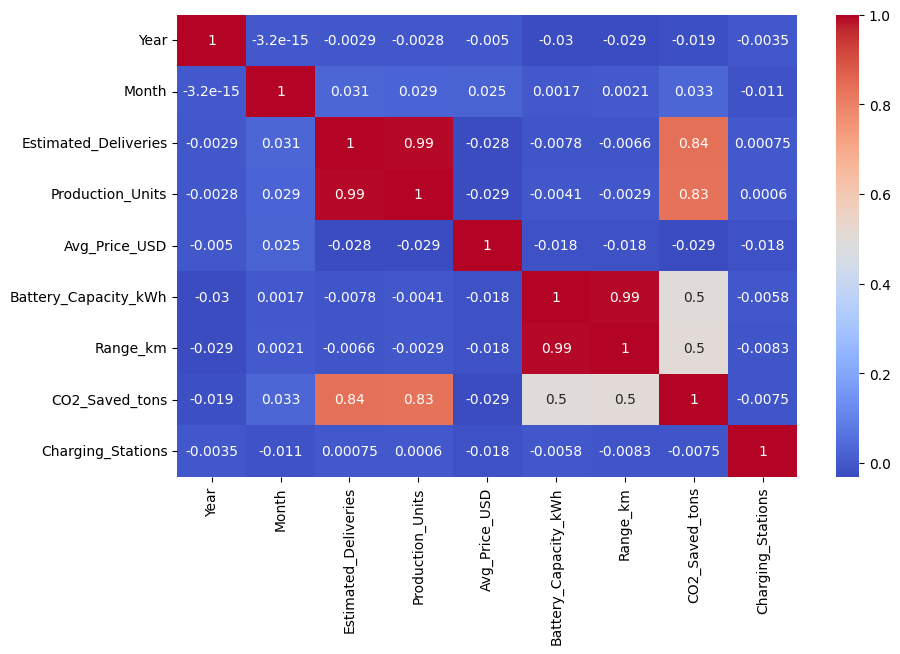

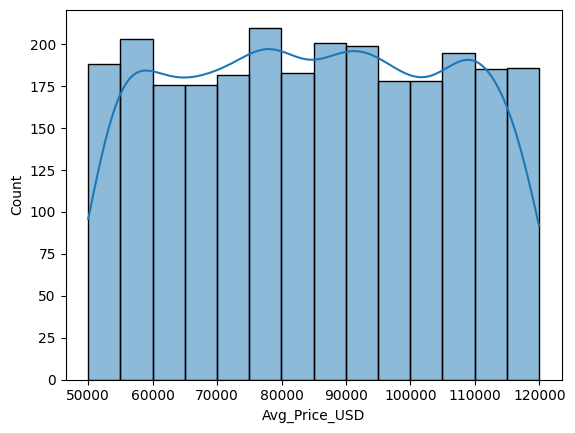

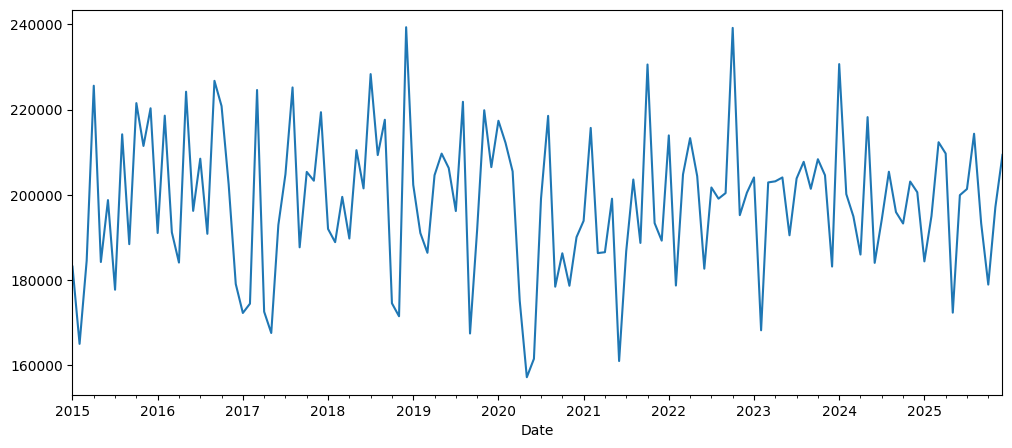

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Information
print(df.info())

# Missing Values
print(df.isnull().sum())

# Statistical Summary
print(df.describe())

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.show()

# Price Distribution
sns.histplot(df["Avg_Price_USD"], kde=True)
plt.show()

# Sales Trend
monthly_sales = df.groupby("Date")["Estimated_Deliveries"].sum()

monthly_sales.plot(figsize=(12,5))
plt.show()

In [ ]:
# Month & Quarter

df["Month_Number"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter

# Price per Battery Capacity

df["Price_per_kWh"] = (
    df["Avg_Price_USD"] /
    df["Battery_Capacity_kWh"]
)

# Range Efficiency

df["Range_per_kWh"] = (
    df["Range_km"] /
    df["Battery_Capacity_kWh"]
)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

target = "Avg_Price_USD"

X = df.drop(columns=[target, "Date"])
y = df[target]

num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include="object").columns

numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric, num_cols),
    ("cat", categorical, cat_cols)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 230.1015564393903
R2 Score: 0.9993404723465192


In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    "regressor__n_estimators": [100, 200],
    "regressor__max_depth": [10, 20, None],
    "regressor__min_samples_split": [2, 5]
}

grid = GridSearchCV(
    model,
    params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters")
print(grid.best_params_)

print("Best Cross Validation Score")
print(grid.best_score_)

Best Parameters
{'regressor__max_depth': 20, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
Best Cross Validation Score
0.9989721015160298


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


2026-01-01    203819.655291
2026-02-01    202894.176208
2026-03-01    199011.662577
2026-04-01    198667.010489
2026-05-01    200971.493839
2026-06-01    201391.449843
2026-07-01    201412.663910
2026-08-01    201031.409119
2026-09-01    200601.086701
2026-10-01    200710.068214
2026-11-01    200864.721560
2026-12-01    200936.680134
Freq: MS, Name: predicted_mean, dtype: float64


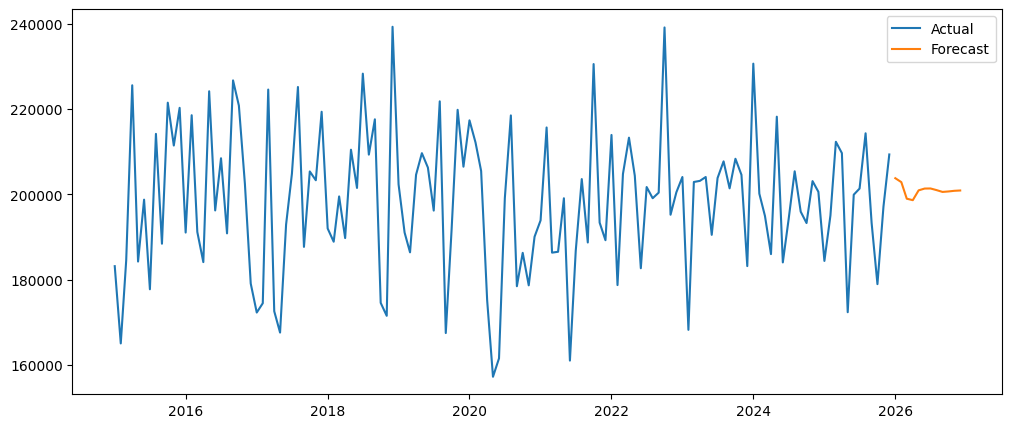

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

sales = df.groupby("Date")["Estimated_Deliveries"].sum()

arima = ARIMA(sales, order=(5,1,0))

model = arima.fit()

forecast = model.forecast(steps=12)

print(forecast)

plt.figure(figsize=(12,5))
plt.plot(sales, label="Actual")
plt.plot(forecast.index, forecast, label="Forecast")
plt.legend()
plt.show()